### Some examples on working/converting NWB data and streaming from dandi

### Streaming video files

In [1]:
import av                                                                                              
from dandi.dandiapi import DandiAPIClient                                                                                                                                                                                                                                                       
from ethograph.utils.nwb_video import NWBDANDIPoseEstimationWidget


# Default example: IBL Brainwide Map (dandiset 000409)
dandiset_id = "000409"
session_eid = "64e3fb86-928c-4079-865c-b364205b502e"

client = DandiAPIClient()
dandiset = client.get_dandiset(dandiset_id, "draft")
session_assets = [asset for asset in dandiset.get_assets() if session_eid in asset.path]

raw_asset = next((asset for asset in session_assets if "desc-raw" in asset.path), None)
processed_asset = next((asset for asset in session_assets if "desc-processed" in asset.path), None)

# Adapated from NWB Video widgets
widget = NWBDANDIPoseEstimationWidget(
    processed_asset=processed_asset,
    raw_asset=raw_asset,
)

nwb = widget.nwbfile
cameras_with_pose = widget.available_cameras
video_info = widget.video_info
video_info # also includes start end time in sesson 

2026-04-05 13:00:26.449 | WARNING  | hdmf.spec.namespace:warn_for_ignored_namespaces:620 - c:\Users\aksel\anaconda3\envs\ethograph\Lib\site-packages\hdmf\spec\namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)



{'VideoBodyCamera': {'url': 'https://dandiarchive.s3.amazonaws.com/blobs/cfa/32c/cfa32c9a-2d2d-4489-bb29-30c7a20fa207',
  'start': 6.577342200006577,
  'end': 4030.4229174040306},
 'VideoLeftCamera': {'url': 'https://dandiarchive.s3.amazonaws.com/blobs/390/b57/390b57b1-8f79-4d19-84ae-6c5d4b20127a',
  'start': 6.532580010006533,
  'end': 4030.4061524140307},
 'VideoRightCamera': {'url': 'https://dandiarchive.s3.amazonaws.com/blobs/f08/c4c/f08c4cf3-729c-4505-8241-2415ddb951a4',
  'start': 6.5000832600065,
  'end': 4030.4301166840305}}

In [2]:
cameras_with_pose

['RightCamera', 'LeftCamera', 'BodyCamera']

frames: 241609, rate: 60, duration: 4026.8s
(1024, 1280, 3)


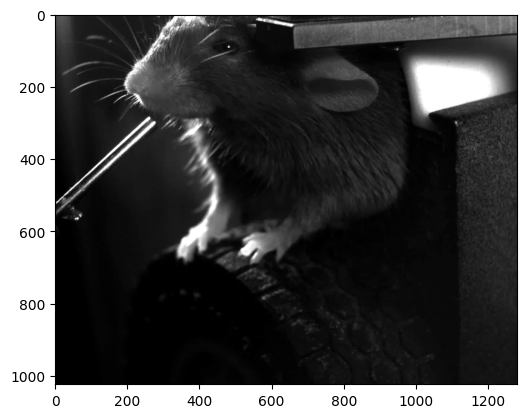

In [6]:
import matplotlib.pyplot as plt


container = av.open(video_info["VideoLeftCamera"]["url"])
stream = container.streams.video[0]
print(f"frames: {stream.frames}, rate: {stream.average_rate}, duration: {float(stream.duration * stream.time_base):.1f}s")

# Read a single frame
for frame in container.decode(video=0):
    img = frame.to_ndarray(format="rgb24")
    print(img.shape)
    plt.imshow(img)
    plt.show()

    break


container.close()

### In case you lose the webpage url, this code identifies the neurosift links to specific session_eids

In [ ]:
import requests

dandiset_id = "000409"
session_eid = "64e3fb86-928c-4079-865c-b364205b502e"

resp = requests.get(
    f"https://api.dandiarchive.org/api/dandisets/{dandiset_id}/versions/draft/assets/",
    params={"glob": f"*{session_eid}*", "page_size": 50},
).json()

for a in resp["results"]:
    asset_id = a["asset_id"]
    print(a["path"])
    print(f"https://neurosift.app/nwb?url=https://api.dandiarchive.org/api/assets/{asset_id}/download/&dandisetId={dandiset_id}&dandisetVersion=draft")
    print()

### Streaming ephys

In [40]:
from ethograph.utils.nwb import probe_electrical_series


x = probe_electrical_series(nwb)
x

[]

### Multiple video files per camera

https://github.com/catalystneuro/nwb-video-widgets/issues/34

In [1]:
from datetime import datetime
from uuid import uuid4
from zoneinfo import ZoneInfo
from pathlib import Path

from pynwb import NWBFile, NWBHDF5IO
from pynwb.image import ImageSeries
from pynwb.file import Subject

video_dir = Path(r"C:\Users\aksel\Desktop\pair24")
videos = sorted(video_dir.glob("*.mp4"))

cameras: dict[str, list[tuple[int, Path]]] = {}
for v in videos:
    # "cam-1_frame-0.mp4" -> cam="1", frame=0
    parts = v.stem.split("_")
    cam = parts[0].split("-")[1]
    frame = int(parts[1].split("-")[1])
    cameras.setdefault(cam, []).append((frame, v))

for cam in cameras:
    cameras[cam].sort(key=lambda x: x[0])

nwbfile = NWBFile(
    session_description="Pair24 behavioral session",
    identifier=str(uuid4()),
    session_start_time=datetime(2025, 7, 9, 20, 0, 0, tzinfo=ZoneInfo("Europe/Berlin")),
    subject=Subject(
        subject_id="pair24",
        species="mouse",
    ),
)

for cam_id, segments in sorted(cameras.items()):
    external_files = [str(path) for _, path in segments]
    starting_frames = [frame for frame, _ in segments]

    cam_series = ImageSeries(
        name=f"cam{cam_id}",
        description=f"Camera {cam_id}, {len(segments)} segments",
        external_file=external_files,
        format="external",
        starting_frame=starting_frames,
        rate=30.0,
        unit="n.a.",
    )
    nwbfile.add_acquisition(cam_series)

out_path = video_dir / "pair24.nwb"
with NWBHDF5IO(str(out_path), "w") as io:
    io.write(nwbfile)


In [7]:
from pynwb import read_nwb
from nwb_video_widgets import NWBLocalVideoPlayer

nwbfile = read_nwb(out_path)
widget = NWBLocalVideoPlayer(nwbfile)
widget